# Predictive Modeling for Customer Churn in Telecommunications
**Objective:** To develop a binary classification model to identify at-risk customers using behavioral and usage metrics.

# 1. Environment Setup & Library Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from collections import Counter

## 2. Data Acquisition
We begin by segregating our entire dataset into 2 categories: training (80%) and testing (20%).

In [ ]:
test = pd.read_csv("churn-bigml-20.csv")
train = pd.read_csv("churn-bigml-80.csv")

print(f"Training Shape: {train.shape}")
display(train.head())
train.info()

Training Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

## 3. Exploratory Data Analysis
We begin by analyzing the class distribution and feature correlations to identify patterns in customer behavior.

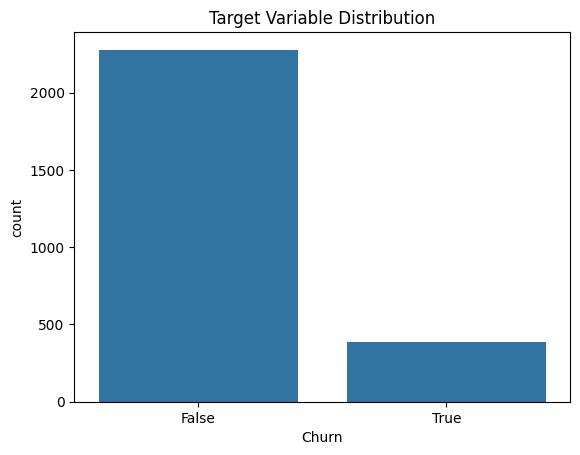

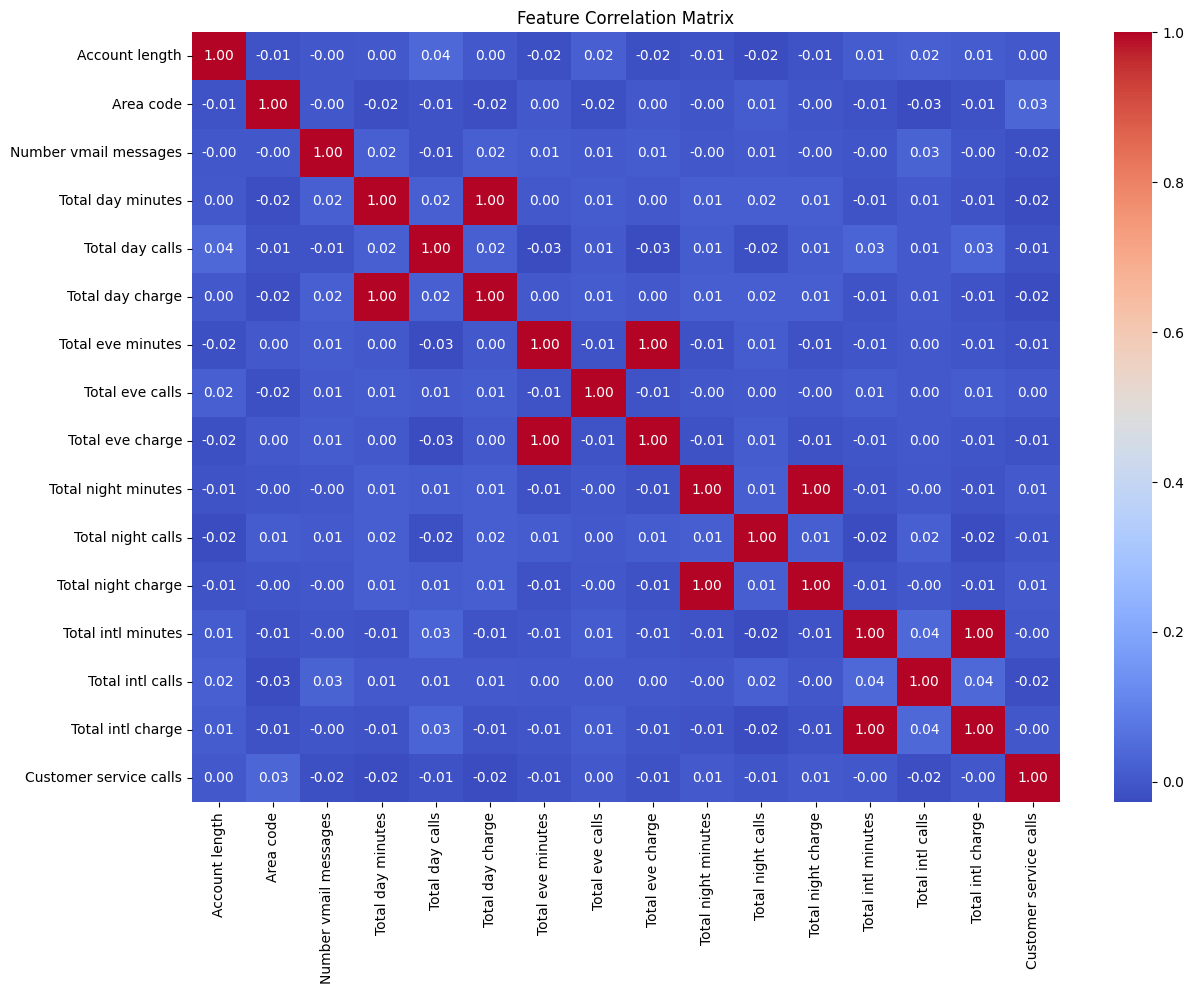

In [11]:
# Churn Distribution
sns.countplot(x="Churn", data=train)
plt.title("Target Variable Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(train.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## 4. Data Preprocessing & Categorical Encoding
We encode categorical variables and remove non-predictive identifiers (e.g., Phone Number) to prepare the feature matrix.

In [12]:
# Drop non-predictive identifiers
train = train.drop(columns=["Phone number"], errors="ignore")
test = test.drop(columns=["Phone number"], errors="ignore")

# Label Encoding for Categorical Columns
le = LabelEncoder()
categorical_cols = ["State", "International plan", "Voice mail plan"]

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

train["Churn"] = train["Churn"].astype(int)
test["Churn"] = test["Churn"].astype(int)

# Splitting Features and Target
X_train = train.drop("Churn", axis=1)
y_train = train["Churn"]
X_test = test.drop("Churn", axis=1)
y_test = test["Churn"]

## 5. Resampling (SMOTE) & Feature Scaling
Since churners are a minority class (~15%), we apply Synthetic Minority Over-sampling Technique (SMOTE) to the training set to prevent model bias.

In [13]:
# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled dataset shape: {Counter(y_train_res)}")

# Standardize features
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

Resampled dataset shape: Counter({0: 2278, 1: 2278})


## 6. Logistic Regression & Feature Importance
We utilize Logistic Regression for its interpretability. Performance is measured using Accuracy, Recall, and a Confusion Matrix.
We use 5-fold cross-validation to ensure model stability and extract coefficients to identify the primary drivers of churn.

Accuracy: 0.7226386806596702
              precision    recall  f1-score   support

           0       0.94      0.72      0.82       572
           1       0.30      0.72      0.42        95

    accuracy                           0.72       667
   macro avg       0.62      0.72      0.62       667
weighted avg       0.85      0.72      0.76       667

--- 5-Fold Cross-Validation ---
Scores: [0.70285088 0.75411636 0.75631175 0.75411636 0.73326015]
Average CV Accuracy: 0.7401


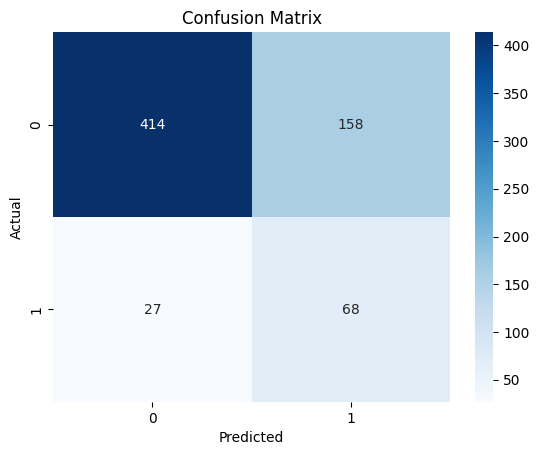

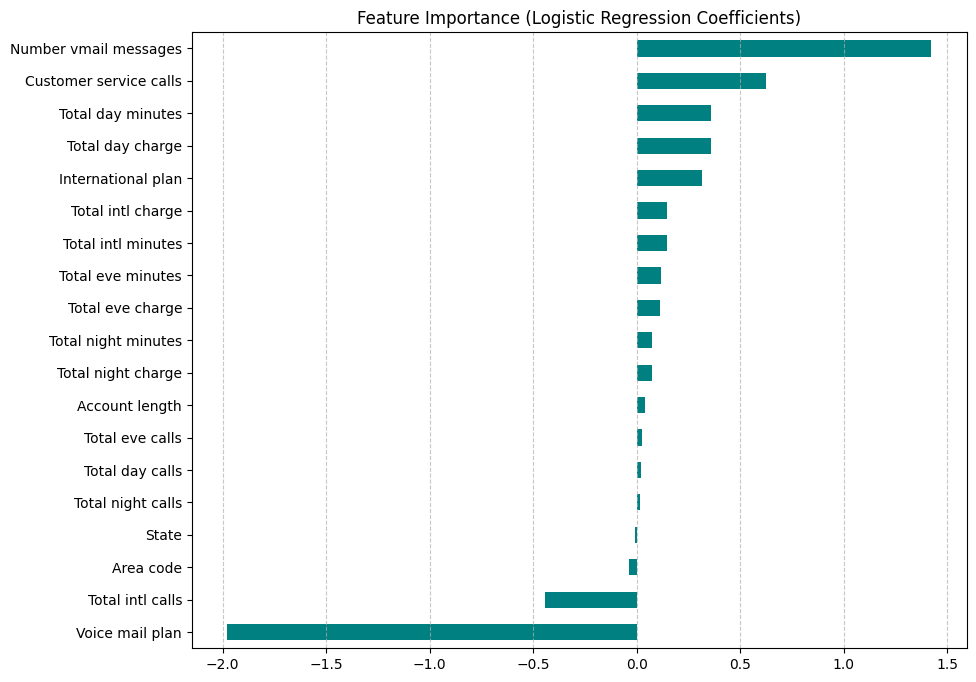

In [14]:
# Training
model = LogisticRegression(max_iter=5000)
model.fit(X_train_res, y_train_res)

# Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 5-Fold Cross-Validation for Stability Check
# We use the resampled training data to check how stable the model is across folds
cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=5)
print("--- 5-Fold Cross-Validation ---")
print(f"Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature Importance
plt.figure(figsize=(10, 8))
importance = model.coef_[0]
features = pd.Series(importance, index=X_train.columns)
features.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()